# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# DESAFIO 1 — Construção e inspeção do DataFrame

dados = pd.DataFrame(registros)

dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
print("Quantidade de linhas:", dados.shape[0])
print("Quantidade de colunas:", dados.shape[1])

Quantidade de linhas: 336
Quantidade de colunas: 11


In [ ]:
print("Atributos do DataFrame:")
print(dados.columns.tolist())

Atributos do DataFrame:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe(include="all")

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# DESAFIO 2 — Organização dos dados
# 1 - Renomear

dados = dados.rename(columns={
    "cod_areacarga": "area",
    "din_referenciautc": "data_hora",
    "val_cargaglobal": "carga"
})

In [ ]:
# 2 - Selecionar os atributos

dados_tratados = dados[
    ["data_hora", "area", "carga"]
].copy()

dados_tratados.head()

,data_hora,area,carga
0,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01T05:30:00.000Z,SP,13838.488


In [ ]:
# 3 - Valores ausentes

dados_tratados.isnull().sum()

,0
data_hora,0
area,0
carga,0


In [ ]:
# 4 - Conversões

dados_tratados["carga"] = pd.to_numeric(
    dados_tratados["carga"],
    errors="coerce"
)

dados_tratados["data_hora"] = pd.to_datetime(
    dados_tratados["data_hora"],
    errors="coerce"
)

In [ ]:
# 5 - Conferência final

print(dados_tratados.dtypes)
print("\nValores ausentes:")
print(dados_tratados.isnull().sum())

display(dados_tratados.head())

data_hora    datetime64[ns, UTC]
area                      object
carga                    float64
dtype: object

Valores ausentes:
data_hora    0
area         0
carga        0
dtype: int64


,data_hora,area,carga
0,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01 05:30:00+00:00,SP,13838.488


### Decisões de tratamento dos dados

Para facilitar a análise, os principais atributos do conjunto de dados
foram renomeados. O atributo `cod_areacarga` foi renomeado para `area`,
`din_referenciautc` para `data_hora` e `val_cargaglobal` para `carga`.

Foi criado um novo DataFrame chamado `dados_tratados`, contendo apenas
os atributos necessários para a análise: data/hora da medição, área de
carga e valor da carga global.

Foi realizada a verificação de valores ausentes utilizando
`isnull().sum()`, permitindo identificar possíveis dados faltantes nas
variáveis analisadas.

A variável `carga` foi convertida para formato numérico utilizando
`pd.to_numeric()`, garantindo que possa ser utilizada nos cálculos
estatísticos das próximas etapas.

A variável `data_hora`, originalmente recebida da API como texto, foi
convertida para o formato datetime utilizando `pd.to_datetime()`.
A informação de horário está representada em UTC.

Caso algum valor não possa ser convertido corretamente, o parâmetro
`errors="coerce"` fará com que ele seja representado como valor ausente,
permitindo sua posterior identificação e tratamento.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# DESAFIO 3 — Indicadores da carga elétrica

carga_minima = dados_tratados["carga"].min()
carga_maxima = dados_tratados["carga"].max()
carga_media = dados_tratados["carga"].mean()
mediana = dados_tratados["carga"].median()
amplitude = carga_maxima - carga_minima
total_medicoes = dados_tratados["carga"].count()

print(f"Carga mínima: {carga_minima:.2f}")
print(f"Carga máxima: {carga_maxima:.2f}")
print(f"Carga média: {carga_media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Quantidade total de medições: {total_medicoes}")

Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06
Quantidade total de medições: 336


In [ ]:
diferenca_max_media = carga_maxima - carga_media

percentual_acima_media = (
    diferenca_max_media / carga_media
) * 100

print(f"Diferença entre máximo e média: {diferenca_max_media:.2f}")
print(f"Máximo acima da média: {percentual_acima_media:.2f}%")

Diferença entre máximo e média: 5314.48
Máximo acima da média: 29.74%


### Análise do valor máximo

A carga máxima registrada foi de **23.185,31**, enquanto a carga média foi de **17.870,83** e a mediana foi de **18.199,13**.

A diferença entre o valor máximo e a média foi de **5.314,48**, o que representa aproximadamente **29,74% acima da média**.

Além disso, a amplitude total observada no período foi de **11.046,06**, considerando uma carga mínima de **12.139,25** e máxima de **23.185,31**.

Com base nesses indicadores, o valor máximo está acima do comportamento médio observado, porém não pode ser considerado extremamente distante da média. Isso porque o pico máximo representa cerca de **29,74% acima da carga média**. A proximidade entre a média (**17.870,83**) e a mediana (**18.199,13**) também indica que os valores centrais da série apresentam comportamento relativamente consistente.

Portanto, o valor máximo pode ser interpretado como um pico de carga relevante dentro do período analisado, mas não como um valor completamente fora do padrão geral observado.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# DESAFIO 4 — Períodos de alta demanda

limiar_alta_demanda = carga_maxima * 0.90

alta_demanda = dados_tratados[
    dados_tratados["carga"] > limiar_alta_demanda
].copy()

quantidade_alta_demanda = len(alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / total_medicoes
) * 100

maior_carga_alta_demanda = alta_demanda["carga"].max()

indice_pico = dados_tratados["carga"].idxmax()
pico = dados_tratados.loc[indice_pico]

print("PERÍODOS DE ALTA DEMANDA")
print("-" * 35)

print(f"Limiar de alta demanda: {limiar_alta_demanda:.2f}")
print(f"Quantidade de registros: {quantidade_alta_demanda}")
print(f"Percentual em relação ao total: {percentual_alta_demanda:.2f}%")
print(f"Maior valor de carga: {maior_carga_alta_demanda:.2f}")
print(f"Data e horário do pico: {pico['data_hora']}")

PERÍODOS DE ALTA DEMANDA
-----------------------------------
Limiar de alta demanda: 20866.78
Quantidade de registros: 50
Percentual em relação ao total: 14.88%
Maior valor de carga: 23185.31
Data e horário do pico: 2025-08-01 22:00:00+00:00


### Análise dos períodos de alta demanda

Foi considerado como período de alta demanda todo registro com carga superior a 90% da carga máxima.

O limiar calculado foi de **20.866,78**. Foram identificados **50 registros** acima desse valor, o que corresponde a aproximadamente **14,88% do total de medições**.

O maior valor de carga observado foi de **23.185,31**, registrado em **01/08/2025 às 22:00 UTC**.

Com base nesses resultados, os períodos próximos ao pico representam uma **parcela pequena do período analisado**, pois somente **14,88% das medições** ficaram acima de 90% da carga máxima.

Isso mostra que os níveis mais elevados de carga ocorreram de forma relativamente pontual, enquanto a maior parte das medições permaneceu abaixo do limiar de alta demanda.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# DESAFIO 5 — Segundo critério de análise

# Critério: carga acima da média

acima_media = dados_tratados[
    dados_tratados["carga"] > carga_media
].copy()

quantidade_acima_media = len(acima_media)

percentual_acima_media_registros = (
    quantidade_acima_media / total_medicoes
) * 100

print("SEGUNDO CRITÉRIO — CARGA ACIMA DA MÉDIA")
print("-" * 45)

print(f"Carga média: {carga_media:.2f}")
print(f"Quantidade de registros: {quantidade_acima_media}")
print(
    f"Percentual em relação ao total: "
    f"{percentual_acima_media_registros:.2f}%"
)

print("\nCOMPARAÇÃO COM ALTA DEMANDA")
print("-" * 45)

print(
    f"Acima da média: {quantidade_acima_media} registros "
    f"({percentual_acima_media_registros:.2f}%)"
)

print(
    f"Alta demanda: {quantidade_alta_demanda} registros "
    f"({percentual_alta_demanda:.2f}%)"
)

display(acima_media.head())

SEGUNDO CRITÉRIO — CARGA ACIMA DA MÉDIA
---------------------------------------------
Carga média: 17870.83
Quantidade de registros: 184
Percentual em relação ao total: 54.76%

COMPARAÇÃO COM ALTA DEMANDA
---------------------------------------------
Acima da média: 184 registros (54.76%)
Alta demanda: 50 registros (14.88%)


,data_hora,area,carga
15,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01 13:00:00+00:00,SP,19427.822


### Segundo critério de análise

O segundo critério escolhido foi considerar os registros com carga
superior à carga média do período analisado.

A carga média calculada foi de **17.870,83**.

Com esse critério, foram encontrados **184 registros**, correspondendo
a aproximadamente **54,76% do total de 336 medições**.

No conjunto de alta demanda, definido anteriormente como cargas
superiores a 90% da carga máxima, foram encontrados **50 registros**,
equivalentes a **14,88% do total**.

Dessa forma, o recorte de carga acima da média é mais abrangente do que
o recorte de alta demanda. Isso ocorre porque estar acima da média não
significa necessariamente estar próximo do valor máximo.

O conjunto de alta demanda representa apenas os momentos de carga mais
elevada, enquanto o conjunto acima da média inclui também valores
intermediários que superam o comportamento médio do período.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

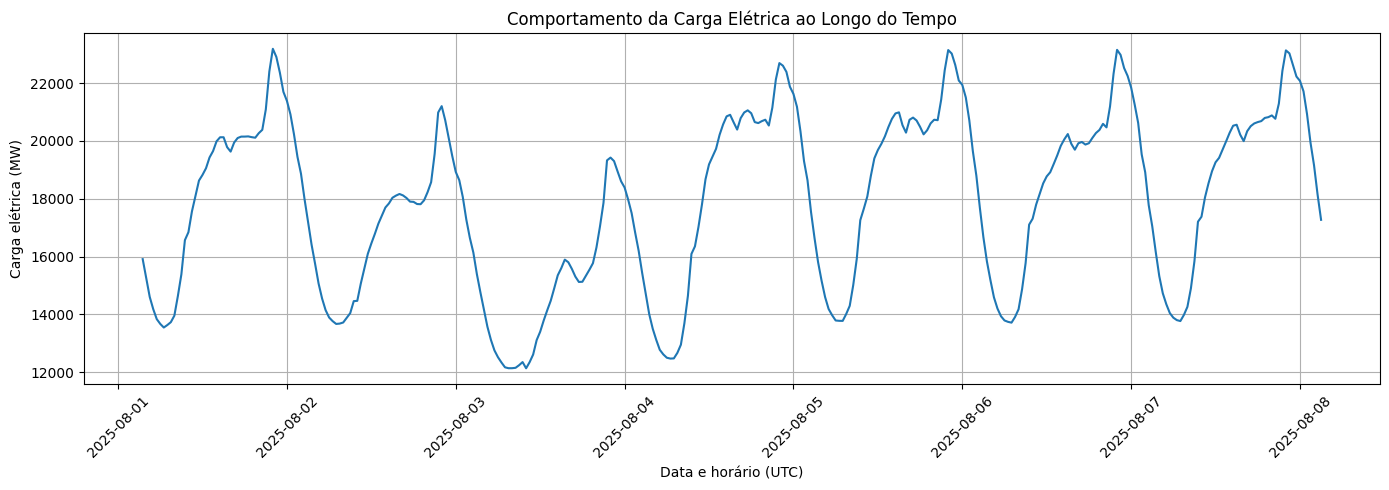

In [ ]:
# GRÁFICO 1 — Comportamento da carga ao longo do tempo

plt.figure(figsize=(14, 5))

plt.plot(
    dados_tratados["data_hora"],
    dados_tratados["carga"]
)

plt.title("Comportamento da Carga Elétrica ao Longo do Tempo")
plt.xlabel("Data e horário (UTC)")
plt.ylabel("Carga elétrica (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Interpretação do gráfico 1

O gráfico mostra que a carga elétrica apresenta variações ao longo do período analisado, com momentos de aumento e redução da demanda.

O maior pico observado foi de aproximadamente **23.185,31 MW**, enquanto o menor valor registrado foi de aproximadamente **12.139,25 MW**.

Essas oscilações indicam que o consumo de energia não permanece constante ao longo do tempo, apresentando períodos de maior e menor demanda.

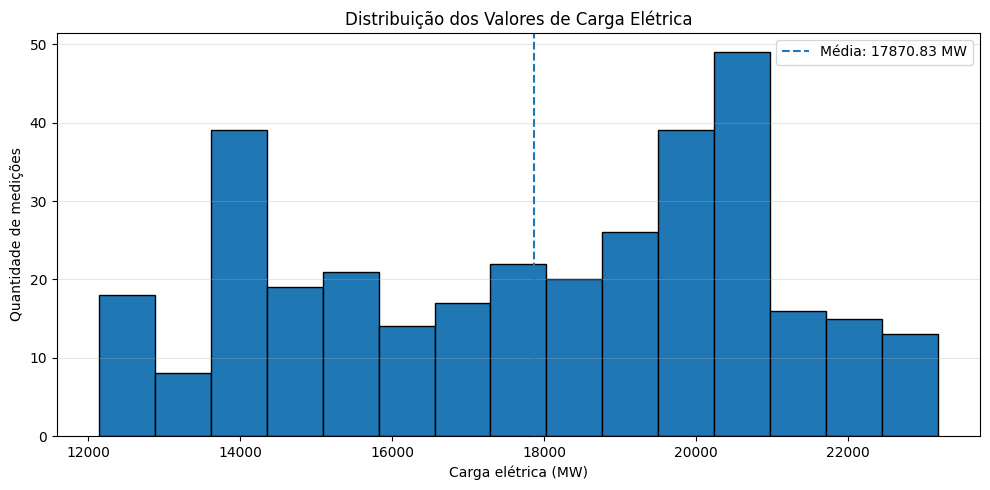

In [ ]:
# GRÁFICO 2 — Distribuição dos valores de carga

plt.figure(figsize=(10, 5))

plt.hist(
    dados_tratados["carga"],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    carga_media,
    linestyle="--",
    label=f"Média: {carga_media:.2f} MW"
)

plt.title("Distribuição dos Valores de Carga Elétrica")
plt.xlabel("Carga elétrica (MW)")
plt.ylabel("Quantidade de medições")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Interpretação do gráfico 2

O histograma apresenta a distribuição das medições de carga elétrica durante o período analisado.

É possível observar em quais faixas de carga ocorreu a maior concentração de registros. A linha tracejada representa a carga média, de aproximadamente **17.870,83 MW**.

A distribuição mostra que grande parte das observações se concentra em torno dos valores intermediários, enquanto valores próximos ao máximo de **23.185,31 MW** aparecem com menor frequência.

Esse resultado é consistente com a análise de alta demanda, na qual apenas **14,88% das medições** ficaram acima de 90% da carga máxima.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# DESAFIO 7 — Síntese para o relatório

momento_pico = pico["data_hora"].strftime("%d/%m/%Y %H:%M UTC")

resumo_resultados = f"""
Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025

Quantidade de registros: {total_medicoes}

Carga mínima: {carga_minima:.2f}
Carga máxima: {carga_maxima:.2f}
Carga média: {carga_media:.2f}
Mediana: {mediana:.2f}

Limiar de alta demanda (90% da carga máxima): {limiar_alta_demanda:.2f}
Registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%

Momento do pico: {momento_pico}
Valor da carga no pico: {pico["carga"]:.2f}

Segundo critério: carga acima da média de {carga_media:.2f}
Quantidade de registros acima da média: {quantidade_acima_media}
Percentual de registros acima da média: {percentual_acima_media_registros:.2f}%
"""

print(resumo_resultados)


Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025

Quantidade de registros: 336

Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13

Limiar de alta demanda (90% da carga máxima): 20866.78
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%

Momento do pico: 01/08/2025 22:00 UTC
Valor da carga no pico: 23185.31

Segundo critério: carga acima da média de 17870.83
Quantidade de registros acima da média: 184
Percentual de registros acima da média: 54.76%



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

**Para:** Diretoria / Gestão Operacional  
**Setor:** Análise de Dados / Setor Elétrico  
**Assunto:** Avaliação do perfil de demanda de carga — Região SP  

---

### 1. Caracterização do conjunto analisado

O presente relatório analisa o comportamento da carga elétrica na região de São Paulo (SP) durante o período de 01/08/2025 a 07/08/2025. 

* **Região:** SP — São Paulo
* **Período de Amostragem:** 01/08/2025 a 07/08/2025
* **Volume de Dados:** 336 registros

---

### 2. Principais indicadores

Os dados consolidados de demanda de carga para a região e período informados apresentam os seguintes parâmetros estatísticos:

* **Carga Mínima:** 12.139,25
* **Carga Máxima (Pico):** 23.185,31
* **Carga Média:** 17.870,83
* **Mediana:** 18.199,13

**Observação temporal de pico:** O ponto de carga máxima registrada (23.185,31) ocorreu no dia 01/08/2025 às 22:00 UTC. 

---

### 3. Análise dos períodos de alta demanda

O limiar para definição 

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

## DESAFIO 9 — Validação crítica

### 1. Os indicadores foram utilizados corretamente?

Sim. Os principais indicadores calculados pela equipe foram utilizados corretamente no relatório gerado pelo Gemini.

Foram apresentados corretamente:

- carga mínima: **12.139,25**;
- carga máxima: **23.185,31**;
- carga média: **17.870,83**;
- mediana: **18.199,13**;
- limiar de alta demanda: **20.866,78**;
- quantidade de registros de alta demanda: **50**;
- percentual de alta demanda: **14,88%**;
- momento do pico: **01/08/2025 às 22:00 UTC**;
- registros acima da média: **184**;
- percentual acima da média: **54,76%**.

Esses valores foram comparados com os resultados obtidos diretamente pelos códigos executados no notebook.

### 2. Há alguma afirmação que não pode ser confirmada pelos dados?

Sim. O relatório gerado inicialmente utilizou a expressão **"o sistema operou em patamar crítico"** para descrever os registros acima de 90% da carga máxima.

Essa afirmação não pode ser confirmada apenas pelos dados analisados, pois o critério de 90% da carga máxima foi definido pela equipe apenas como um limite para classificar registros de alta demanda.

Os dados não fornecem informações suficientes para determinar se esse nível representa efetivamente uma situação crítica para o sistema elétrico.

Também não é possível determinar, com os dados disponíveis, quais foram as causas dos picos e das variações observadas.

### 3. Houve interpretação exagerada ou causalidade não demonstrada?

Houve uma pequena interpretação exagerada no uso de expressões como **"patamar crítico"** e **"eventos mais extremos da rede"**.

Essas expressões sugerem uma condição operacional do sistema que não foi diretamente analisada.

Entretanto, o relatório não afirmou como fatos possíveis causas externas, como temperatura, comportamento de consumo ou condições operacionais. Esses fatores foram apresentados apenas como hipóteses que exigiriam dados adicionais para serem investigados.

Portanto, não houve causalidade diretamente inventada, mas algumas expressões foram revisadas para evitar conclusões mais fortes do que os dados permitem.

### 4. Que alterações a equipe realizou no texto?

A equipe realizou as seguintes alterações:

- substituiu a expressão **"patamar crítico"** por **"registros acima do limiar de alta demanda"**;
- substituiu **"eventos mais extremos da rede"** por **"valores mais elevados observados no conjunto de dados"**;
- deixou explícito que o critério de alta demanda corresponde a valores **superiores a 90% da carga máxima**;
- substituiu afirmações relacionadas a "tempo de operação" por referências à quantidade ou percentual de **medições**, pois essa é a informação diretamente calculada;
- manteve a separação entre resultados observados e possíveis hipóteses;
- ajustou a conclusão para apresentar apenas afirmações sustentadas pelos cálculos realizados no notebook.

# RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA

## 1. Caracterização do conjunto analisado

O presente relatório apresenta uma análise da carga elétrica da região de São Paulo (SP), utilizando dados obtidos por meio da API pública de Carga Verificada do Operador Nacional do Sistema Elétrico (ONS).

O período analisado corresponde a **01/08/2025 a 07/08/2025**, totalizando **336 registros**.

A análise foi realizada a partir dos atributos de data e horário, região e valor da carga elétrica.

---

## 2. Principais indicadores

Os cálculos realizados sobre o conjunto de dados apresentaram os seguintes resultados:

- **Carga mínima:** 12.139,25
- **Carga máxima:** 23.185,31
- **Carga média:** 17.870,83
- **Mediana:** 18.199,13
- **Amplitude entre máximo e mínimo:** 11.046,06
- **Quantidade total de medições:** 336

O maior valor de carga registrado foi de **23.185,31**, enquanto a média foi de **17.870,83**.

O valor máximo ficou aproximadamente **29,74% acima da média**. Dessa forma, o pico está acima do comportamento médio observado, mas não representa um valor completamente isolado do restante da distribuição.

A proximidade entre a média e a mediana também indica que os valores centrais do conjunto apresentam comportamento relativamente consistente.

---

## 3. Períodos de alta demanda

Foi definido como critério de alta demanda todo registro com carga superior a **90% da carga máxima**.

O limiar calculado foi de:

**20.866,78**

Foram encontrados:

- **50 registros de alta demanda**;
- correspondentes a **14,88% das 336 medições**.

O maior valor registrado foi de **23.185,31**, ocorrido em **01/08/2025 às 22:00 UTC**.

Como apenas **14,88% das medições** ficaram acima do limiar estabelecido, os valores próximos ao pico representam uma parcela relativamente pequena do conjunto analisado.

Isso indica que as cargas mais elevadas ocorreram em um número menor de observações quando comparadas ao total de registros.

---

## 4. Segundo critério de análise

Como segundo critério, foram selecionados os registros cuja carga ficou acima da média de **17.870,83**.

Foram identificados:

- **184 registros acima da média**;
- correspondentes a **54,76% do total de medições**.

Esse resultado é significativamente maior do que o encontrado no critério de alta demanda.

Enquanto o critério de carga acima da média inclui **54,76% das observações**, o critério de alta demanda inclui somente **14,88%**.

Isso ocorre porque o critério de carga acima da média é mais abrangente, enquanto o limiar de 90% da carga máxima seleciona apenas os valores mais elevados do conjunto.

---

## 5. Análise visual

O gráfico de carga ao longo do tempo demonstrou variações recorrentes durante o período analisado, permitindo identificar períodos de crescimento, redução e ocorrência do valor máximo.

O gráfico de distribuição mostrou a concentração das medições em torno dos valores intermediários, enquanto os valores próximos ao máximo ocorreram com menor frequência.

As visualizações são compatíveis com os indicadores calculados, especialmente com o resultado de que apenas **14,88% das medições** foram classificadas como alta demanda.

---

## 6. Resultados observados e hipóteses

Os dados analisados permitem afirmar que:

- a carga variou entre **12.139,25 e 23.185,31**;
- o maior valor ocorreu em **01/08/2025 às 22:00 UTC**;
- **14,88% das medições** ficaram acima de 90% da carga máxima;
- **54,76% das medições** ficaram acima da carga média.

Entretanto, os dados utilizados não permitem determinar as causas das variações observadas.

Fatores como temperatura, condições meteorológicas, comportamento de consumo, características econômicas ou condições operacionais poderiam ser investigados em análises futuras, mas não podem ser apresentados como explicações para os resultados deste estudo sem dados adicionais.

---

## 7. Conclusão

A análise dos **336 registros** da região de São Paulo permitiu caracterizar o comportamento da carga elétrica durante o período de 01/08/2025 a 07/08/2025.

A carga média observada foi de **17.870,83**, enquanto o maior valor registrado foi de **23.185,31**, ocorrido em **01/08/2025 às 22:00 UTC**.

Os registros classificados como alta demanda representaram **14,88% das medições**, mostrando que os valores próximos ao máximo ocorreram em uma parcela relativamente pequena do conjunto.

Por outro lado, **54,76% das medições** apresentaram carga acima da média, mostrando que o segundo critério é consideravelmente mais abrangente.

A comparação dos dois critérios evidencia a diferença entre analisar valores simplesmente superiores ao comportamento médio e selecionar apenas registros próximos ao maior valor observado.

Por fim, os resultados permitem descrever quantitativamente o comportamento da carga elétrica no período analisado, mas não permitem determinar as causas das variações. Para isso, seriam necessários dados complementares.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**